In [ ]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SHEET_ID = "1eCmFmUINutfH4zC90frNxKj6HB4wunNoXvZlWVed2yk"
GID = "0"  # aba Página1
url_tsv = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=tsv&gid={GID}"

# TSV + vírgula decimal
df = pd.read_csv(url_tsv, sep="\t", decimal=",")

print("Colunas lidas:", list(df.columns))
display(df.head())

Colunas lidas: ['idade', 'renda_mensal', 'score_credito', 'risco']


,idade,renda_mensal,score_credito,risco
0,22,1800,450,alto
1,25,2200,500,alto
2,28,2500,580,medio
3,30,3000,620,medio
4,35,4500,700,baixo


In [ ]:
FEATURES = ["idade", "renda_mensal", "score_credito"]


TARGET = "risco"            # coluna F (classe)

for col in FEATURES :
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Normaliza o target e remove linhas inválidas
df[TARGET] = df[TARGET].astype(str).str.strip().str.lower()
df = df.dropna(subset=FEATURES + [TARGET]).copy() #remove linhas com valores inválidos

print("\nDistribuição do target:")
print(df[TARGET].value_counts())



Distribuição do target:
risco
baixo    20
medio    12
alto      8
Name: count, dtype: int64


In [ ]:
le = LabelEncoder()
y_all = le.fit_transform(df[TARGET])
X_all = df[FEATURES].values

print("\nClasses:", list(le.classes_))
print("Total linhas válidas:", len(df))


Classes: ['alto', 'baixo', 'medio']
Total linhas válidas: 40


In [ ]:

RANDOM_STATE = 42
df_shuffled = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
limite_teste=int(len(df)*0.20) # Split : 20% teste + 80% treino
test_df  = df_shuffled.iloc[:limite_teste].copy()
train_df = df_shuffled.iloc[limite_teste:len(df)].copy()
X_train = train_df[FEATURES].values
y_train = le.transform(train_df[TARGET])
X_test  = test_df[FEATURES].values
y_test  = le.transform(test_df[TARGET])
print("\nTreino:", len(train_df), "| Teste:", len(test_df))



Treino: 32 | Teste: 8


In [ ]:
def dist_classes(frame, target_col, titulo):
    vc = frame[target_col].value_counts(dropna=False)
    pct = (vc / len(frame) * 100).round(1)
    out = pd.DataFrame({"qtd": vc, "%": pct})
    print(f"\n=== {titulo} (n={len(frame)}) ===")
    display(out)

dist_classes(df, TARGET, "Dataset completo")
dist_classes(train_df, TARGET, "Treino")
dist_classes(test_df, TARGET, "Teste")


=== Dataset completo (n=40) ===


,qtd,%
risco,,
baixo,20,50.0
medio,12,30.0
alto,8,20.0



=== Treino (n=32) ===


,qtd,%
risco,,
baixo,13,40.6
medio,11,34.4
alto,8,25.0



=== Teste (n=8) ===


,qtd,%
risco,,
baixo,7,87.5
medio,1,12.5


In [ ]:
# Modelo KNN
K = 5
WEIGHTS = "distance"  # "uniform" ou "distance"

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=K, weights=WEIGHTS))
])

model.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(weights='distance'))])

In [ ]:
# Avaliação

y_pred = model.predict(X_test)

print("\nFeatures usadas:", FEATURES)
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório:")
print(classification_report(
    y_test,
    y_pred,
    labels=range(len(le.classes_)),
    target_names=le.classes_,
    zero_division=0
))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred))



Features usadas: ['idade', 'renda_mensal', 'score_credito']
Acurácia: 1.0

Relatório:
              precision    recall  f1-score   support

        alto       0.00      0.00      0.00         0
       baixo       1.00      1.00      1.00         7
       medio       1.00      1.00      1.00         1

    accuracy                           1.00         8
   macro avg       0.67      0.67      0.67         8
weighted avg       1.00      1.00      1.00         8

Matriz de confusão (real x previsto):
[[7 0]
 [0 1]]


In [ ]:
# Resultado detalhado do teste
test_df["classe_prevista"] = le.inverse_transform(y_pred)
display(test_df[FEATURES + [TARGET, "classe_prevista"]])

,idade,renda_mensal,score_credito,risco,classe_prevista
0,26,2400,560,medio,medio
1,48,5800,770,baixo,baixo
2,36,4700,705,baixo,baixo
3,44,5400,740,baixo,baixo
4,35,4500,700,baixo,baixo
5,42,5200,730,baixo,baixo
6,38,4750,705,baixo,baixo
7,46,5600,760,baixo,baixo



=== Árvore de decisão ===
Features usadas: ['idade', 'renda_mensal', 'score_credito']
Acurácia: 0.875

Relatório:
              precision    recall  f1-score   support

        alto       0.00      0.00      0.00         0
       baixo       1.00      1.00      1.00         7
       medio       0.00      0.00      0.00         1

    accuracy                           0.88         8
   macro avg       0.33      0.33      0.33         8
weighted avg       0.88      0.88      0.88         8

Matriz de confusão (real x previsto):
[[0 0 0]
 [0 7 0]
 [1 0 0]]


,idade,renda_mensal,score_credito,risco,classe_prevista_arvore
0,26,2400,560,medio,alto
1,48,5800,770,baixo,baixo
2,36,4700,705,baixo,baixo
3,44,5400,740,baixo,baixo
4,35,4500,700,baixo,baixo
5,42,5200,730,baixo,baixo
6,38,4750,705,baixo,baixo
7,46,5600,760,baixo,baixo


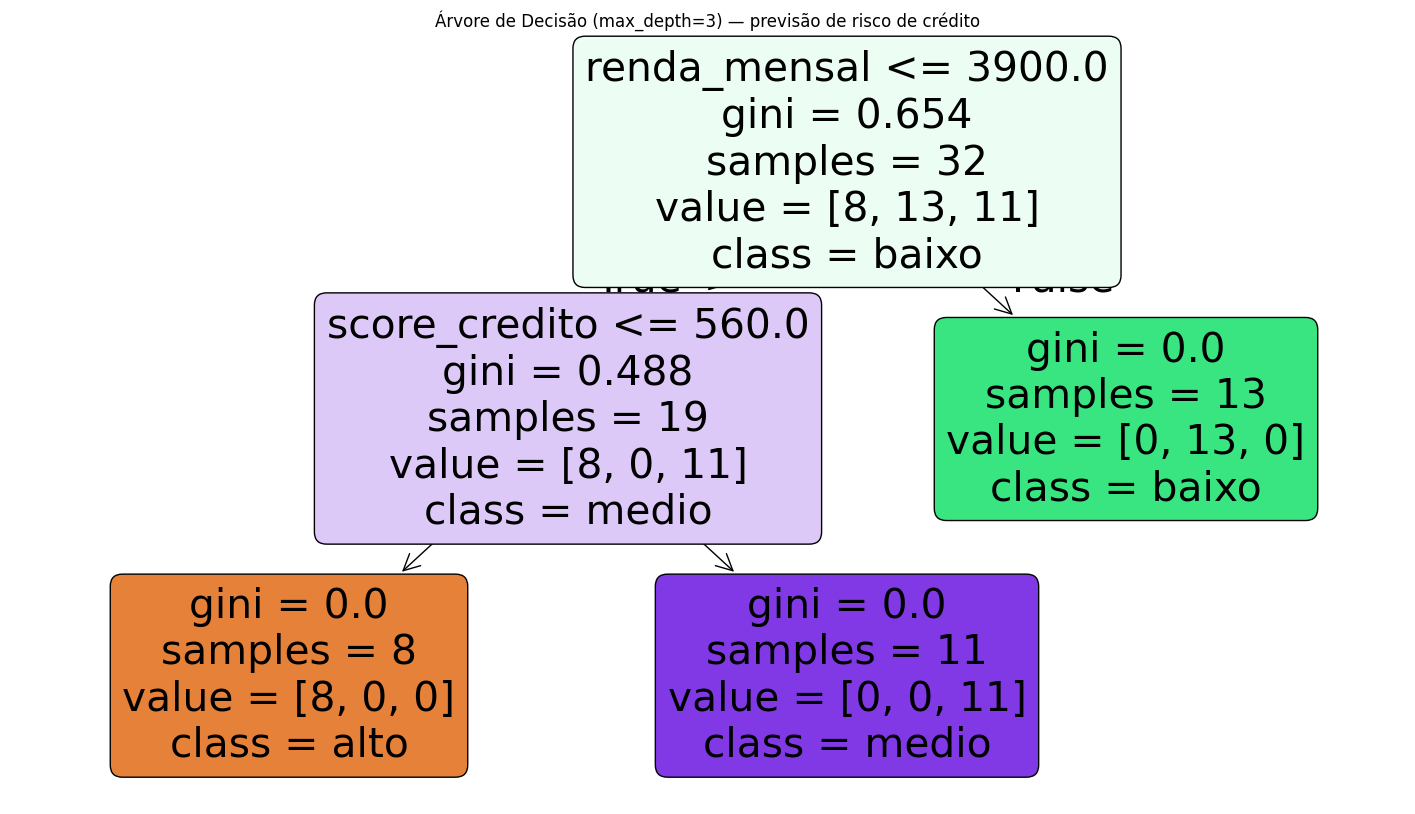

In [ ]:
# ========= Árvore de decisão =========
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE
)

tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("\n=== Árvore de decisão ===")
print("Features usadas:", FEATURES)
print("Acurácia:", accuracy_score(y_test, y_pred_tree))
print("\nRelatório:")
print(classification_report(
    y_test,
    y_pred_tree,
    labels=range(len(le.classes_)),
    target_names=le.classes_,
    zero_division=0
))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred_tree))

# Resultado detalhado
test_df["classe_prevista_arvore"] = le.inverse_transform(y_pred_tree)
display(test_df[FEATURES + [TARGET, "classe_prevista_arvore"]])

# desenhar árvore
plt.figure(figsize=(18, 10))
plot_tree(
    tree,
    feature_names=FEATURES,
    class_names=list(le.classes_),
    filled=True,
    rounded=True,
    impurity=True
)
plt.title("Árvore de Decisão (max_depth=3) — previsão de risco de crédito")
plt.show()